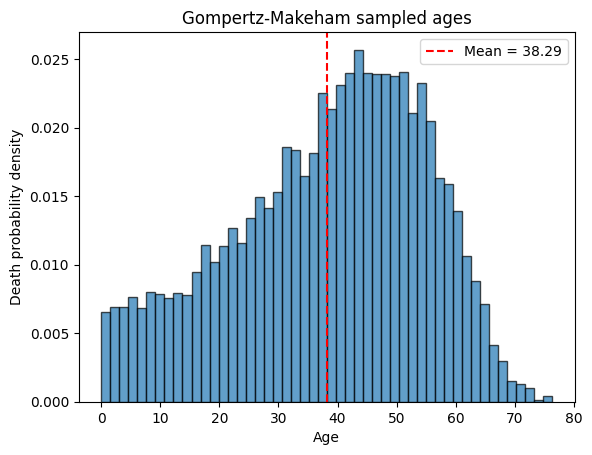

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import rv_continuous

alpha = 0.002
beta = 0.075
lamda = 0.004


class GompertzMakeham(rv_continuous):
    def __init__(self, alpha, beta, lamda, *args, **kwargs):
        super().__init__(a=0.0, *args, **kwargs)
        self.alpha = alpha
        self.beta = beta
        self.lamda = lamda

    def _pdf(self, x):
        # h(x) = alpha * exp(beta*x) + lamda ; f(x) = h(x) * S(x)
        hazard = self.alpha * np.exp(self.beta * x) + self.lamda
        survival = np.exp(
            -(self.alpha / self.beta) * (np.exp(self.beta * x) - 1.0)
            - self.lamda * x
        )
        return hazard * survival

    def _rvs(self, size=None, random_state=None):
        if random_state is None:
            random_state = self._random_state

        u = random_state.uniform(size=size)
        z = -np.log1p(-u)

        def solve_one(target):
            def equation(x):
                return (
                    (self.alpha / self.beta) * (np.exp(self.beta * x) - 1.0)
                    + self.lamda * x
                    - target
                )

            hi = 1.0
            while equation(hi) < 0:
                hi *= 2.0
            return brentq(equation, 0.0, hi)

        return np.vectorize(solve_one, otypes=[float])(z)


gompertz_makeham = GompertzMakeham(alpha, beta, lamda, name="gompertz_makeham")
values = gompertz_makeham.rvs(size=10000)
mean = np.mean(values)

plt.hist(values, bins=50, density=True, edgecolor="black", alpha=0.7)
plt.axvline(mean, color="red", linestyle="dashed", linewidth=1.5, label=f"Mean = {mean:.2f}")
plt.xlabel("Age")
plt.ylabel("Death probability density")
plt.title("Gompertz-Makeham sampled ages")
plt.legend()
plt.show()

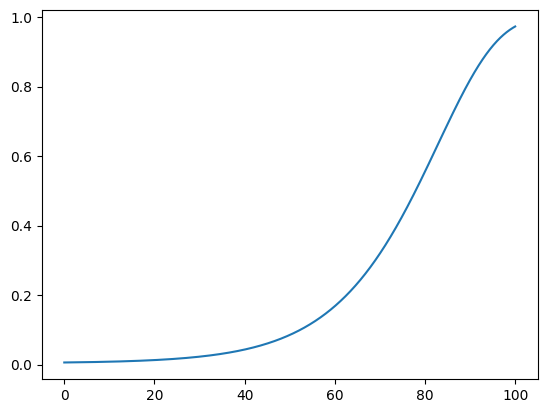

In [4]:
x = np.linspace(0, 100, 1000)
def mu(x):
    return alpha * np.exp(beta * x) + lamda
plt.plot(x, 1-np.exp(-mu(x)))
plt.show()